In [1]:
# 1 — 2025 deep-sea container calls with vessel attributes
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

candidates = [Path.cwd(), *Path.cwd().parents]
BASE = next((p for p in candidates if (p / "data" / "processed").exists()), None)
if BASE is None:
    raise FileNotFoundError(f"data/processed not found from {Path.cwd()} - run from inside the project folder.")
PROC = BASE / "data" / "processed"

calls = pd.read_csv(PROC / "calls_2024_2025.csv", parse_dates=["ts_arrival", "ts_berth", "ts_unberth"])
calls = calls[(calls["navigation"] == "Longo Curso") & (calls["year"] == 2025)].copy()
calls["imo"] = pd.to_numeric(calls["imo"], errors="coerce")
calls["berth_h"] = (calls["ts_unberth"] - calls["ts_berth"]).dt.total_seconds() / 3600

tab = pd.read_csv(PROC / "tabela_completa.csv").rename(columns={"IMO": "imo"})
df = calls.merge(tab, on="imo", how="left", validate="m:1")
df["has_vessel"] = df["Nome_Navio"].notna()

print(f"2025 deep-sea container calls: {len(df):,} | TEU moved: {df['teu'].sum():,.0f}")
print(f"With vessel attributes: {100 * df['has_vessel'].mean():.1f}% of calls, "
      f"{100 * df.loc[df['has_vessel'], 'teu'].sum() / df['teu'].sum():.1f}% of TEU | "
      f"{df.loc[df['has_vessel'], 'imo'].nunique()} vessels\n")

v = df[df["has_vessel"]]
attrs = ["TEU_Capacidade", "Classe_Navio", "Ano_Construcao", "LOA", "DWT", "Bandeira",
         "Armador_Operador", "Estrutura_Titularidade"]
filled = v.drop_duplicates("imo")[attrs].notna().mean() * 100
print("Share of identified vessels with each attribute filled (%):")
print(filled.round(1).to_string(), "\n")
print("Ownership values:", v.drop_duplicates("imo")["Estrutura_Titularidade"].value_counts(dropna=False).to_dict())

2025 deep-sea container calls: 6,653 | TEU moved: 11,188,988
With vessel attributes: 80.7% of calls, 90.5% of TEU | 324 vessels

Share of identified vessels with each attribute filled (%):
TEU_Capacidade            100.0
Classe_Navio              100.0
Ano_Construcao            100.0
LOA                       100.0
DWT                       100.0
Bandeira                  100.0
Armador_Operador          100.0
Estrutura_Titularidade    100.0 

Ownership values: {'Propria': 243, 'Afretada': 79, 'Afretada Provisoria': 2}


In [2]:
# 2 — The typical vessel of Brazil's deep-sea container trade: per vessel, per call, per TEU moved
v = df[df["has_vessel"]].copy()
v["age"] = 2025 - v["Ano_Construcao"]

def wmedian(x, w):
    d = pd.DataFrame({"x": x, "w": w}).dropna().sort_values("x")
    return d["x"][d["w"].cumsum() / d["w"].sum() >= 0.5].iloc[0] if len(d) else np.nan

views = {
    "per vessel": v.drop_duplicates("imo").assign(w=1.0),
    "per call": v.assign(w=1.0),
    "per TEU moved": v.assign(w=v["teu"]),
}
CLASS_ORDER = ["Feeder / Sub-Panamax", "Panamax", "Neo-Panamax", "Large Post-Panamax", "Ultra Large (ULCS)"]

cls = pd.DataFrame({k: 100 * d.groupby("Classe_Navio")["w"].sum() / d["w"].sum() for k, d in views.items()})
print("Vessel class mix (%):")
print(cls.reindex(CLASS_ORDER).round(1).to_string(), "\n")

prof = pd.DataFrame({k: {"median capacity (TEU)": wmedian(d["TEU_Capacidade"], d["w"]),
                         "median age (years)": wmedian(d["age"], d["w"]),
                         "median LOA (m)": wmedian(d["LOA"], d["w"]),
                         "median TEU moved per call": wmedian(d["teu"], d["w"]) if k != "per vessel" else np.nan}
                     for k, d in views.items()})
print("Typical vessel (weighted medians):")
print(prof.round(0).to_string(), "\n")

own = pd.DataFrame({k: 100 * d.groupby("Estrutura_Titularidade", dropna=False)["w"].sum() / d["w"].sum()
                    for k, d in views.items()})
print("Ownership structure (%):")
print(own.round(1).to_string(), "\n")

for col, n in [("Bandeira", 6), ("Armador_Operador", 8)]:
    t = pd.DataFrame({k: 100 * d.groupby(col)["w"].sum() / d["w"].sum() for k, d in views.items()})
    print(f"Top {col} (%):")
    print(t.sort_values("per TEU moved", ascending=False).head(n).round(1).to_string(), "\n")

Vessel class mix (%):
                      per vessel  per call  per TEU moved
Classe_Navio                                             
Feeder / Sub-Panamax        11.4      12.2            9.3
Panamax                     17.0      16.6           11.7
Neo-Panamax                 48.8      48.8           49.5
Large Post-Panamax          21.0      19.7           24.8
Ultra Large (ULCS)           1.9       2.7            4.8 

Typical vessel (weighted medians):
                           per vessel  per call  per TEU moved
median capacity (TEU)          8010.0    8010.0         8700.0
median age (years)               12.0      12.0           11.0
median LOA (m)                  299.0     299.0          299.0
median TEU moved per call         NaN    1639.0         2433.0 

Ownership structure (%):
                        per vessel  per call  per TEU moved
Estrutura_Titularidade                                     
Afretada                      24.4      22.2           17.3
Afretada Prov

In [3]:
# 3 — Vessel-level features and k-means clustering, checked against vessel class
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

vf = (v.groupby("imo").agg(name=("Nome_Navio", "first"), cls=("Classe_Navio", "first"),
                          operator=("Armador_Operador", "first"), ownership=("Estrutura_Titularidade", "first"),
                          capacity=("TEU_Capacidade", "first"), age=("age", "first"),
                          calls=("call_id", "size"), teu_per_call=("teu", "median"), berth_h=("berth_h", "median")))
vf = vf[vf["calls"] >= 3].copy()
vf["exchange_ratio"] = vf["teu_per_call"] / vf["capacity"]
for c in ["capacity", "teu_per_call", "berth_h", "calls"]:
    vf[f"log_{c}"] = np.log(vf[c])
FEATS = ["log_capacity", "age", "log_teu_per_call", "log_berth_h", "log_calls"]
X = StandardScaler().fit_transform(vf[FEATS])
print(f"Vessels with >= 3 calls in 2025: {len(vf)} (of {v['imo'].nunique()})\n")

print("Correlation between features:")
print(vf[FEATS].corr().round(2).to_string(), "\n")

rows = []
for k in range(2, 9):
    labels = [KMeans(k, n_init=20, random_state=s).fit_predict(X) for s in range(5)]
    rows.append({"k": k, "silhouette": silhouette_score(X, labels[0]),
                 "ARI_vs_class": adjusted_rand_score(vf["cls"], labels[0]),
                 "stability_ARI_across_seeds": np.mean([adjusted_rand_score(labels[0], l) for l in labels[1:]])})
print(pd.DataFrame(rows).set_index("k").round(3).to_string())

Vessels with >= 3 calls in 2025: 308 (of 324)

Correlation between features:
                  log_capacity   age  log_teu_per_call  log_berth_h  log_calls
log_capacity              1.00 -0.38              0.47         0.05      -0.05
age                      -0.38  1.00             -0.34        -0.19       0.00
log_teu_per_call          0.47 -0.34              1.00         0.59      -0.21
log_berth_h               0.05 -0.19              0.59         1.00      -0.25
log_calls                -0.05  0.00             -0.21        -0.25       1.00 

   silhouette  ARI_vs_class  stability_ARI_across_seeds
k                                                      
2       0.249         0.120                       1.000
3       0.247         0.129                       0.982
4       0.263         0.134                       1.000
5       0.241         0.192                       0.825
6       0.213         0.191                       0.863
7       0.226         0.213                       0.937

In [4]:
# 4 — Four vessel groups: profile, class mix, operators and example vessels
K = 4
km = KMeans(K, n_init=20, random_state=0).fit(X)
dist = km.transform(X)
vf["group_raw"] = km.labels_
vf["dist_to_centre"] = dist[np.arange(len(vf)), km.labels_]
order = vf.groupby("group_raw")["capacity"].median().sort_values().index
vf["group"] = vf["group_raw"].map({g: i + 1 for i, g in enumerate(order)})

teu_by_group = v[v["imo"].isin(vf.index)].assign(group=lambda d: d["imo"].map(vf["group"])) \
    .groupby("group")["teu"].sum()
prof_g = vf.groupby("group").agg(
    vessels=("name", "size"), capacity=("capacity", "median"), age=("age", "median"),
    teu_per_call=("teu_per_call", "median"), berth_h=("berth_h", "median"), calls_2025=("calls", "median"),
    exchange_ratio_pct=("exchange_ratio", lambda s: 100 * s.median()),
    chartered_pct=("ownership", lambda s: 100 * s.str.startswith("Afretada").mean()))
prof_g["share_of_TEU_pct"] = 100 * teu_by_group / teu_by_group.sum()
print("Group profile (medians):")
print(prof_g.round(1).to_string(), "\n")

print("Vessel class mix within each group (% of vessels):")
print((pd.crosstab(vf["group"], vf["cls"], normalize="index") * 100)
      .reindex(columns=CLASS_ORDER).fillna(0).round(0).to_string(), "\n")

ops = pd.crosstab(vf["group"], vf["operator"], normalize="index") * 100
print("Main operators within each group (% of vessels):")
print(ops[ops.sum().sort_values(ascending=False).index[:7]].round(0).to_string(), "\n")

print("Example vessels closest to each group's centre:")
ex = vf.sort_values("dist_to_centre").groupby("group").head(4).sort_values(["group", "dist_to_centre"])
print(ex[["group", "name", "cls", "operator", "capacity", "age", "calls", "teu_per_call", "berth_h"]]
      .round(1).to_string(index=False))

Group profile (medians):
       vessels  capacity   age  teu_per_call  berth_h  calls_2025  exchange_ratio_pct  chartered_pct  share_of_TEU_pct
group                                                                                                                 
1           18    2736.5  12.0        2276.5     48.5         8.5                80.1           22.2               4.8
2           90    4464.0  17.0        1188.2     18.7        23.0                24.1           34.4              25.8
3           83    8580.0  14.0        1962.0     22.2         7.0                23.7           37.3              12.6
4          117   10034.0   9.0        2154.0     23.0        21.0                20.4            8.5              56.7 

Vessel class mix within each group (% of vessels):
cls    Feeder / Sub-Panamax  Panamax  Neo-Panamax  Large Post-Panamax  Ultra Large (ULCS)
group                                                                                    
1                      61.0 

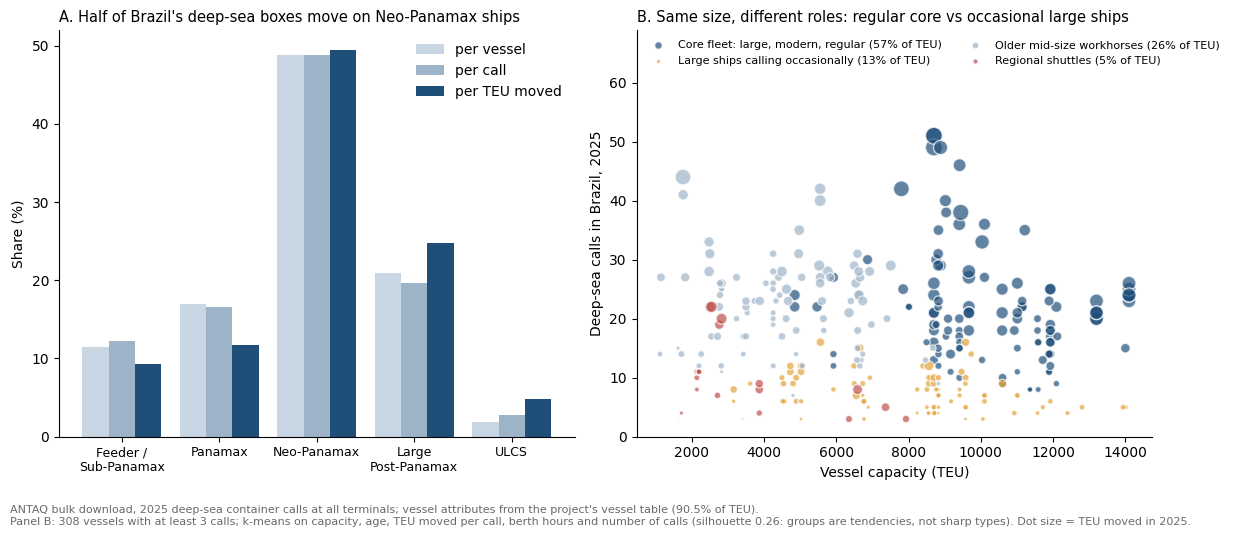

In [5]:
# 5 — Figure (fig12): the typical vessel and the four fleet groups
FIG_DIR = BASE / "outputs" / "figures"
GROUP_NAMES = {4: "Core fleet: large, modern, regular", 2: "Older mid-size workhorses",
               3: "Large ships calling occasionally", 1: "Regional shuttles"}
GROUP_COLORS = {4: "#1f4e79", 2: "#9db4c8", 3: "#e3a33b", 1: "#c0504d"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

short_cls = ["Feeder /\nSub-Panamax", "Panamax", "Neo-Panamax", "Large\nPost-Panamax", "ULCS"]
xx = np.arange(len(CLASS_ORDER))
for i, (col, c) in enumerate([("per vessel", "#c9d6e3"), ("per call", "#9db4c8"), ("per TEU moved", "#1f4e79")]):
    vals = cls[col].reindex(CLASS_ORDER).fillna(0)
    ax1.bar(xx + (i - 1) * 0.27, vals, width=0.27, color=c, label=col)
ax1.set_xticks(xx, short_cls, fontsize=9)
ax1.set_ylabel("Share (%)")
ax1.set_title("A. Half of Brazil's deep-sea boxes move on Neo-Panamax ships", loc="left", fontsize=10.5)
ax1.legend(frameon=False)

teu_vessel = v.groupby("imo")["teu"].sum()
for g in [4, 3, 2, 1]:
    d = vf[vf["group"] == g]
    ax2.scatter(d["capacity"], d["calls"], s=teu_vessel.reindex(d.index) / 800, color=GROUP_COLORS[g],
                alpha=0.7, edgecolor="white", label=f"{GROUP_NAMES[g]} ({prof_g.loc[g, 'share_of_TEU_pct']:.0f}% of TEU)")
ax2.set_ylim(0, vf["calls"].max() * 1.35)   # empty band at the top for the legend
ax2.set_xlabel("Vessel capacity (TEU)")
ax2.set_ylabel("Deep-sea calls in Brazil, 2025")
ax2.set_title("B. Same size, different roles: regular core vs occasional large ships", loc="left", fontsize=10.5)
leg = ax2.legend(frameon=False, fontsize=8, loc="upper left", ncol=2, markerscale=0.6)

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)

fig.text(0.01, -0.06,
         "ANTAQ bulk download, 2025 deep-sea container calls at all terminals; vessel attributes from the project's vessel table "
         "(90.5% of TEU).\nPanel B: 308 vessels with at least 3 calls; k-means on capacity, age, TEU moved per call, berth hours "
         "and number of calls (silhouette 0.26: groups are tendencies, not sharp types). Dot size = TEU moved in 2025.",
         fontsize=8, color="dimgrey")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig12_fleet_profile.png", dpi=150, bbox_inches="tight")
plt.show()

## What this notebook answers

2025 deep-sea container calls at all terminals. Vessel attributes come from the project's vessel table, which covers 90.5% of TEU moved (324 vessels).

**The typical vessel** in Brazil's deep-sea container trade is a Neo-Panamax of about 8,000–8,700 TEU, 299 m long, 11–12 years old, owned rather than chartered by its operator, flagged in Liberia and run by Maersk or MSC. It moves about 1,600 TEU per call, around a fifth of its capacity, which is what a multi-port rotation looks like.

- **Neo-Panamax ships carry half of the trade** whichever way it is counted: per vessel, per call or per TEU moved.
- **Cargo travels on bigger ships than the average vessel suggests.** Large Post-Panamax and Ultra Large ships are 23% of vessels but 30% of TEU.
- **Chartered ships are smaller or used less.** They are 25% of vessels but 18% of TEU.
- **MSC deploys more ships (29%), Maersk moves more cargo (26.5% of TEU vs 23.2%).**

**Vessel groups.** Clustering 308 vessels on capacity, age, TEU moved per call, berth hours and number of calls gives four groups that differ from vessel class (adjusted Rand index vs class ≈ 0.13). They describe the role a ship plays more than its size:

| Group | Vessels | Median capacity | Median age | Calls in 2025 | Chartered | Share of TEU |
|---|---|---|---|---|---|---|
| Core fleet: large, modern, regular | 117 | 10,034 | 9 | 21 | 9% | 57% |
| Older mid-size workhorses | 90 | 4,464 | 17 | 23 | 34% | 26% |
| Large ships calling occasionally | 83 | 8,580 | 14 | 7 | 37% | 13% |
| Regional shuttles | 18 | 2,737 | 12 | 8.5 | 22% | 5% |

The core fleet and the occasional large ships share the same classes but not the same role: the occasional group calls a third as often, is five years older and is four times as likely to be chartered.

## Limitations

1. **The groups are weak.** Silhouette scores stay between 0.21 and 0.26 for any number of groups, so the fleet varies continuously; the four groups are tendencies, not sharp types, and some vessels sit on the border.
2. **Calls in 2025 depend on when a ship joined or left Brazilian services,** so part of the "occasional" group may simply be ships deployed for part of the year.
3. **Vessel attributes come from a table built for this project** from public sources; ownership in particular may be misclassified for some ships.
4. **The regional-shuttle interpretation is not verified.** It would need the foreign ports of those calls.
5. **No like-for-like age benchmark.** UNCTAD's 12.6 years (2024) covers the whole world fleet weighted by gross tonnage, not container ships alone.
6. **One year only.**